## Playlist Generation — End-to-End

This notebook connects the two halves of the project:

**Part A — Airbnb NLP** (mirrors `Airbnb/airbnb-preprocessing.ipynb` + `Airbnb/airbnb-nlp.ipynb`)
- Load a city CSV
- Select relevant columns
- Clean text, tokenize, remove stopwords, lemmatize
- Extract TF-IDF keywords per listing → `df['keywords']`

**Part B — Spotify Recommendation** (uses `recommendation/keyword_embedder.py` + `recommendation/recommender.py`)
- Load the clustered Spotify dataset
- Pick a listing, inspect its keywords
- Run the 4-layer recommender → ranked playlist

---
| Recommender Layer | Signal | Method |
|---|---|---|
| 1 | **Lyrics match** | Location/place terms searched in song lyrics |
| 2 | **Emotion match** | Keywords embedded → cosine sim to emotion anchors |
| 3 | **Audio cosine** | Keywords → target audio vector → cosine sim per track |
| 4 | **Cluster boost** | Closest K-means centroid to target vector gets a multiplier |

---
## Part A: Airbnb NLP Pipeline

Replicates the logic from `airbnb-preprocessing.ipynb` and `airbnb-nlp.ipynb` on a single city CSV.

### A1. Imports

In [3]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk import bigrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Imports OK")

Imports OK


### A2. Load city CSV and select columns

Mirrors `airbnb-preprocessing.ipynb` — same `columns_to_keep` list, same logic.

In [4]:
# Same columns as airbnb-preprocessing.ipynb
columns_to_keep = [
    "id",
    "listing_url",
    "name",
    "description",
    "neighborhood_overview",
    "neighbourhood_cleansed",
    "property_type",
    "room_type",
    "accommodates",
    "amenities",
]

CITY_CSV = "../Airbnb/Airbnb City Extracts/test-city-1.csv"

raw_df = pd.read_csv(CITY_CSV, low_memory=False)
df = raw_df[[col for col in columns_to_keep if col in raw_df.columns]].copy()

print(f"Loaded {len(df):,} listings")
df.head(3)

Loaded 600 listings


,id,listing_url,name,description,neighborhood_overview,neighbourhood_cleansed,property_type,room_type,accommodates,amenities
0,1913774,https://www.airbnb.com/rooms/1913774,Downtown Bozeman Vacation Rental,Just four easy blocks from historic downtown B...,NaN,Bozeman,Entire guesthouse,Entire home/apt,2,"[""Shower gel"", ""Essentials"", ""Hair dryer"", ""Ex..."
1,1950545,https://www.airbnb.com/rooms/1950545,Northside Hideaway,"Free, fast Wi-Fi for remote learning/working n...",NaN,Bozeman,Entire home,Entire home/apt,4,"[""Essentials"", ""Fire extinguisher"", ""Hair drye..."
2,2390321,https://www.airbnb.com/rooms/2390321,2 Blocks 2 Main,This space is designed for 1-2 people that wan...,I love that it is 2 blocks from the heart of d...,Bozeman,Entire rental unit,Entire home/apt,2,"[""Essentials"", ""Fire extinguisher"", ""Hair drye..."


### A3. EDA: description lengths

Mirrors the EDA section of `airbnb-nlp.ipynb`.

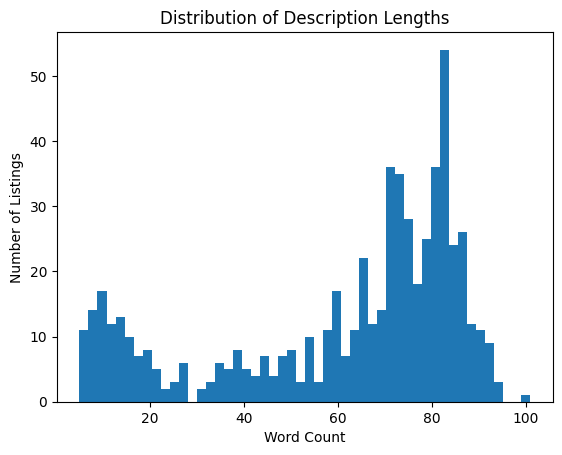

Null descriptions: 5
Listings after dropping nulls: 595


In [5]:
df['char_length'] = df['description'].str.len()
df['word_count']  = df['description'].str.split().str.len()

plt.hist(df['word_count'].dropna(), bins=50)
plt.xlabel("Word Count")
plt.ylabel("Number of Listings")
plt.title("Distribution of Description Lengths")
plt.show()

print(f"Null descriptions: {df['description'].isna().sum()}")
df = df.dropna(subset=['description'])
print(f"Listings after dropping nulls: {len(df):,}")

### A4. Text cleaning

Same `clean_text()` function as `airbnb-nlp.ipynb` — strips numbers, punctuation, extra whitespace.

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)           # remove numbers
    text = re.sub(r'[^\w\s]', '', text)       # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['clean_description'] = df['description'].apply(clean_text)
df[['description', 'clean_description']].sample(3)

,description,clean_description
40,"Beautiful condo in Bozeman Montana, close to s...",beautiful condo in bozeman montana close to sk...
565,"Located conveniently in Bozeman, you’re just m...",located conveniently in bozeman youre just min...
203,"Clean, cheery, centrally-located place.<br />S...",clean cheery centrallylocated placebr str


### A5. Tokenization, stopword removal, lemmatization

Mirrors `airbnb-nlp.ipynb` cells 15–23.

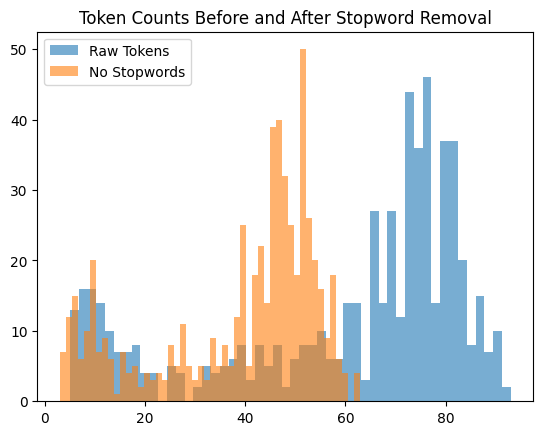

In [7]:
# Tokenize
df['tokens'] = df['clean_description'].apply(word_tokenize)

# Stopword removal
stop_words = set(stopwords.words('english'))
df['tokens_nostop'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

# Token count comparison
df['token_count']       = df['tokens'].apply(len)
df['token_count_nostop'] = df['tokens_nostop'].apply(len)

plt.hist(df['token_count'], bins=50, alpha=0.6, label="Raw Tokens")
plt.hist(df['token_count_nostop'], bins=50, alpha=0.6, label="No Stopwords")
plt.legend()
plt.title("Token Counts Before and After Stopword Removal")
plt.show()

In [8]:
# Most common words before/after stopword removal
all_tokens        = [w for tokens in df['tokens'] for w in tokens]
all_tokens_nostop = [w for tokens in df['tokens_nostop'] for w in tokens]

print("Top 20 raw tokens:")
print(Counter(all_tokens).most_common(20))
print()
print("Top 20 after stopword removal:")
print(Counter(all_tokens_nostop).most_common(20))

Top 20 raw tokens:
[('and', 1550), ('the', 1315), ('to', 1033), ('a', 978), ('in', 641), ('bozeman', 551), ('of', 544), ('with', 532), ('is', 485), ('this', 475), ('for', 474), ('br', 438), ('from', 377), ('downtown', 372), ('your', 281), ('home', 257), ('or', 228), ('located', 215), ('you', 213), ('enjoy', 206)]

Top 20 after stopword removal:
[('bozeman', 551), ('br', 438), ('downtown', 372), ('home', 257), ('located', 215), ('enjoy', 206), ('bridger', 174), ('bedroom', 166), ('perfect', 159), ('condo', 156), ('main', 144), ('street', 140), ('stay', 139), ('kitchen', 135), ('restaurants', 132), ('space', 126), ('minutes', 125), ('private', 123), ('montana', 122), ('walk', 119)]


In [9]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens_lemma'] = df['tokens_nostop'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

# Vocab size comparison
vocab_raw   = set(all_tokens_nostop)
vocab_lemma = set(word for tokens in df['tokens_lemma'] for word in tokens)
print("Vocab size before lemmatization:", len(vocab_raw))
print("Vocab size after lemmatization :", len(vocab_lemma))

Vocab size before lemmatization: 3017
Vocab size after lemmatization : 2768


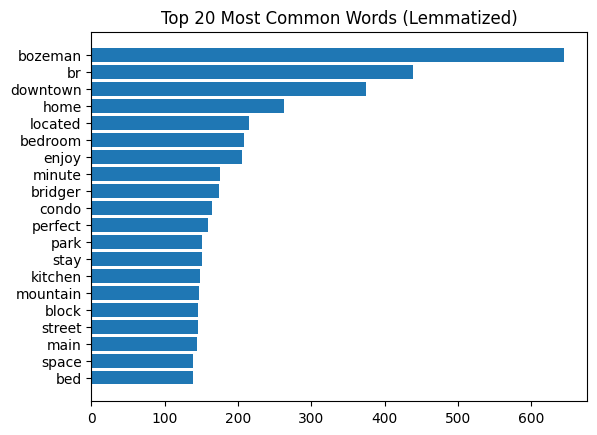

In [10]:
# Top 20 most common words after lemmatization (bar chart)
most_common = Counter(
    word for tokens in df['tokens_lemma'] for word in tokens
).most_common(20)

words, counts = zip(*most_common)
plt.barh(words, counts)
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Words (Lemmatized)")
plt.show()

In [11]:
# Bigram exploration
bigram_list = [
    bigram
    for tokens in df['tokens_lemma']
    for bigram in bigrams(tokens)
]

print("Top 50 bigrams:")
Counter(bigram_list).most_common(50)

Top 50 bigrams:


[(('downtown', 'bozeman'), 148),
 (('big', 'sky'), 101),
 (('main', 'street'), 99),
 (('bridger', 'bowl'), 97),
 (('br', 'br'), 96),
 (('walking', 'distance'), 72),
 (('easy', 'access'), 65),
 (('montana', 'state'), 52),
 (('mountain', 'view'), 50),
 (('state', 'university'), 47),
 (('heart', 'bozeman'), 47),
 (('full', 'kitchen'), 43),
 (('yellowstone', 'national'), 43),
 (('bozeman', 'offer'), 41),
 (('national', 'park'), 41),
 (('centrally', 'located'), 39),
 (('bridger', 'mountain'), 37),
 (('fully', 'equipped'), 36),
 (('queen', 'bed'), 32),
 (('conveniently', 'located'), 32),
 (('block', 'downtown'), 31),
 (('bedroom', 'bath'), 30),
 (('living', 'room'), 29),
 (('home', 'base'), 29),
 (('coffee', 'shop'), 28),
 (('short', 'walk'), 28),
 (('bowl', 'ski'), 27),
 (('minute', 'drive'), 26),
 (('minute', 'downtown'), 26),
 (('block', 'main'), 26),
 (('equipped', 'kitchen'), 26),
 (('shop', 'restaurant'), 25),
 (('natural', 'light'), 25),
 (('within', 'walking'), 25),
 (('minute', 'wal

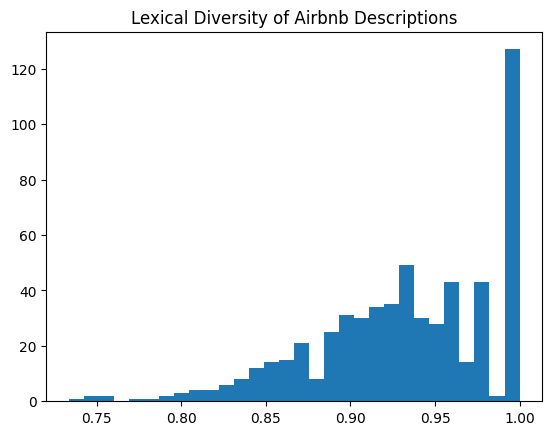

In [12]:
# Lexical diversity
df['unique_ratio'] = df['tokens_lemma'].apply(
    lambda x: len(set(x)) / len(x) if len(x) > 0 else 0
)

plt.hist(df['unique_ratio'], bins=30)
plt.title("Lexical Diversity of Airbnb Descriptions")
plt.show()

### A6. TF-IDF keyword extraction → `df['keywords']`

Mirrors `airbnb-nlp.ipynb` cells 28–30. Same vectorizer settings (`max_df=0.85`, `min_df=5`, `ngram_range=(1,2)`). Produces a list of up to 10 keywords per listing.

In [13]:
df['final_text'] = df['tokens_lemma'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    ngram_range=(1, 2),
)

tfidf_matrix = vectorizer.fit_transform(df['final_text'])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]:,} listings × {tfidf_matrix.shape[1]:,} features")

TF-IDF matrix: 595 listings × 1,379 features


In [14]:
def extract_top_keywords(tfidf_row, feature_names, top_n=10):
    sorted_indices = np.argsort(tfidf_row.toarray()[0])[::-1]
    top_features = [feature_names[i] for i in sorted_indices[:top_n]]
    return top_features

df['keywords'] = [
    extract_top_keywords(tfidf_matrix[i], feature_names, top_n=10)
    for i in range(tfidf_matrix.shape[0])
]

print(f"Keywords extracted for {len(df):,} listings")
df[['name', 'keywords']].head(5)

Keywords extracted for 595 listings


,name,keywords
0,Downtown Bozeman Vacation Rental,"[loft, enjoy private, block historic, perfect ..."
1,Northside Hideaway,"[need keyless, wifi remote, learningworking, l..."
2,2 Blocks 2 Main,"[registration, people, detail, number, want, d..."
3,Modern Home Near Campus & Downtown,"[town, great, queen size, sunny, minute, fence..."
4,"Charming downtown home, Bogart park","[location, hosting permit, lindley, home locat..."


---
## Part B: Spotify Recommendation Pipeline

Takes `df['keywords']` from Part A and generates a playlist for a chosen listing.

### B1. Load the clustered Spotify dataset

Rebuilds `clustered_df` and `scaled_df` using the same steps as `spotify/spotify_clustering.ipynb` with `k=5`.

In [15]:
# Add spotify/ and recommendation/ to path for imports
SPOTIFY_DIR = os.path.abspath("../spotify")
RECO_DIR    = os.path.abspath(".")
for p in [SPOTIFY_DIR, RECO_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from data_loader import (
    AUDIO_FEATURE_COLS,
    load_spotify,
    select_features,
    remove_outliers,
    scale_features,
)
from clustering import fit_kmeans

import importlib
import keyword_embedder
importlib.reload(keyword_embedder)
from keyword_embedder import resolve_keywords, explain_resolution, build_lyric_index

from recommender import recommend

print("Spotify imports OK")

Spotify imports OK


In [16]:
SPOTIFY_PATH = "../spotify/dataset/spotify_dataset_lyrics.csv"

df_spotify = load_spotify(SPOTIFY_PATH)
filtered_df, feature_df = select_features(df_spotify, AUDIO_FEATURE_COLS)
filtered_df, feature_df = remove_outliers(filtered_df, feature_df, AUDIO_FEATURE_COLS)
scaled_df, scaler       = scale_features(feature_df, AUDIO_FEATURE_COLS)

K_FINAL = 5
kmeans, clusters = fit_kmeans(scaled_df, k=K_FINAL)

clustered_df = filtered_df.copy()
clustered_df["cluster"] = clusters

print(f"clustered_df: {clustered_df.shape[0]:,} tracks, {clustered_df.shape[1]} columns")
clustered_df[["track_name", "artist", "genre", "emotion", "cluster"]].head()

Loaded 551443 rows, 21 columns from ../spotify/dataset/spotify_dataset_lyrics.csv
Using 551443 tracks with complete audio features
Flagged 21665 tracks (>±4.0 z-score on any feature)
Retained 529778 tracks after trimming outliers


/usr/local/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


clustered_df: 529,778 tracks, 22 columns


,track_name,artist,genre,emotion,cluster
0,Even When the Waters Cold,!!!,hip hop,sadness,2
1,One Girl / One Boy,!!!,hip hop,sadness,2
2,Pardon My Freedom,!!!,hip hop,joy,4
3,Ooo,!!!,hip hop,joy,2
4,Freedom 15,!!!,hip hop,joy,2


In [17]:
# Build the lyric index for retrieve-then-aggregate audio targeting.
# This embeds all 529k track lyrics once and caches them in memory.
# Takes ~2-3 minutes on first run; subsequent calls in the same session are instant.
build_lyric_index(clustered_df, scaled_df, AUDIO_FEATURE_COLS)

Building lyric index for 529,778 tracks (2070 batches) …


Embedding lyrics:   0%|          | 0/2070 [00:00<?, ?batch/s]

Lyric index ready.


### B2. Pick a listing

Change `LISTING_IDX` to try any listing from the city CSV. The cell prints the full listing details and its extracted keywords.

In [18]:
LISTING_IDX = 7  # change to try a different listing

listing = df.iloc[LISTING_IDX]

print(f"Listing ID   : {listing['id']}")
print(f"Name         : {listing['name']}")
print(f"Neighborhood : {listing.get('neighbourhood_cleansed', 'N/A')}")
print(f"Property type: {listing.get('property_type', 'N/A')}")
print(f"Room type    : {listing.get('room_type', 'N/A')}")
print()
print("Original description:")
print(listing['description'])
print()
print("Extracted keywords:", listing['keywords'])

Listing ID   : 4008507
Name         : The Loft: near MSU, private entry, kitchen & baths
Neighborhood : Bozeman
Property type: Entire guest suite
Room type    : Entire home/apt

Original description:
Our fun & sun-filled Loft has a private entrance, a well-stocked full kitchen, a shower/tub, an enclosed toilet area, a queen & a narrow twin  bed, AC, TV with streaming . . . & an indoor swing! There is a BBQ & an outdoor dining table + two bikes, snow shoes and a full washer/dryer & a 2nd half bath in the garage. We have driveway parking for Loft guests, and are just blocks from the University & historic downtown . . . & BTW, we also AirBnB the main house: airbnb.com/h/montana-mediterranean

Extracted keywords: ['loft', 'full', 'dining table', 'wellstocked', 'driveway parking', 'streaming', 'twin bed', 'snow', 'main house', 'airbnb']


### B3. Inspect keyword resolution

Shows how the embedding model interprets the listing's keywords — which emotions it infers, what audio target vector it derives, and which terms are routed to the lyrics-search layer.

In [19]:
keywords = listing['keywords']
explain_resolution(keywords)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== Keyword Embedding Resolution ===
Input keywords   : ['loft', 'full', 'dining table', 'wellstocked', 'driveway parking', 'streaming', 'twin bed', 'snow', 'main house', 'airbnb']
Location terms   : ['dining table']  ← searched in lyrics

Emotion weights (zero-shot NLI):
  surprise     0.426  █████████████████
  joy          0.359  ██████████████
  neutral      0.175  ██████
  fear         0.018  
  sadness      0.013  
  anger        0.010  

Audio target vector [retrieve-then-aggregate]:
  danceability         -0.539  -
  energy               -0.652  -
  loudness             -0.799  --
  speechiness          -0.546  -
  acousticness         +0.902  ++
  instrumentalness     +0.224  
  liveness             -0.105  
  tempo                -0.295  
  duration_s           +0.116  
  popularity           -0.250  


### B4. Generate the playlist

In [20]:
playlist = recommend(
    keywords=keywords,
    df=clustered_df,
    scaled_df=scaled_df,
    top_n=20,
)

display_cols = [
    "track_name", "artist", "genre", "emotion", "cluster",
    "score", "score_lyrics", "score_emotion", "score_audio", "score_cluster",
]
playlist[display_cols]

,track_name,artist,genre,emotion,cluster,score,score_lyrics,score_emotion,score_audio,score_cluster
0,Lockdown On Date Night Tuesday,Ondara,hip hop,sadness,0,0.768099,1.0,0.25,0.822397,1.0
1,All the Stars,The Wailin' Jennys,folk,surprise,0,0.639831,0.0,1.00,0.959323,1.0
2,Where Did You Get That Hat?,Dennis Marsh,hip hop,surprise,0,0.639783,0.0,1.00,0.959132,1.0
3,Then I Saw You,Tatiana Manaois,hip hop,surprise,0,0.639637,0.0,1.00,0.958550,1.0
4,I Am a Clown,David Cassidy,hip hop,surprise,0,0.639396,0.0,1.00,0.957583,1.0
5,The Curtain Falls,Bobby Darin,"rock,pop,jazz",surprise,0,0.639311,0.0,1.00,0.957245,1.0
6,Hes Always Been Faithful,Sara Groves,hip hop,surprise,0,0.639148,0.0,1.00,0.956593,1.0
7,White Boy,"Paul Kantner,Grace Slick,David Freiberg",hip hop,surprise,0,0.639148,0.0,1.00,0.956592,1.0
8,Little Christmas Tree,Nat King Cole Trio,hip hop,surprise,0,0.638503,0.0,1.00,0.954011,1.0
9,oceans,Halina Heron,hip hop,surprise,0,0.638180,0.0,1.00,0.952721,1.0


### B5. Score breakdown — what drove each recommendation

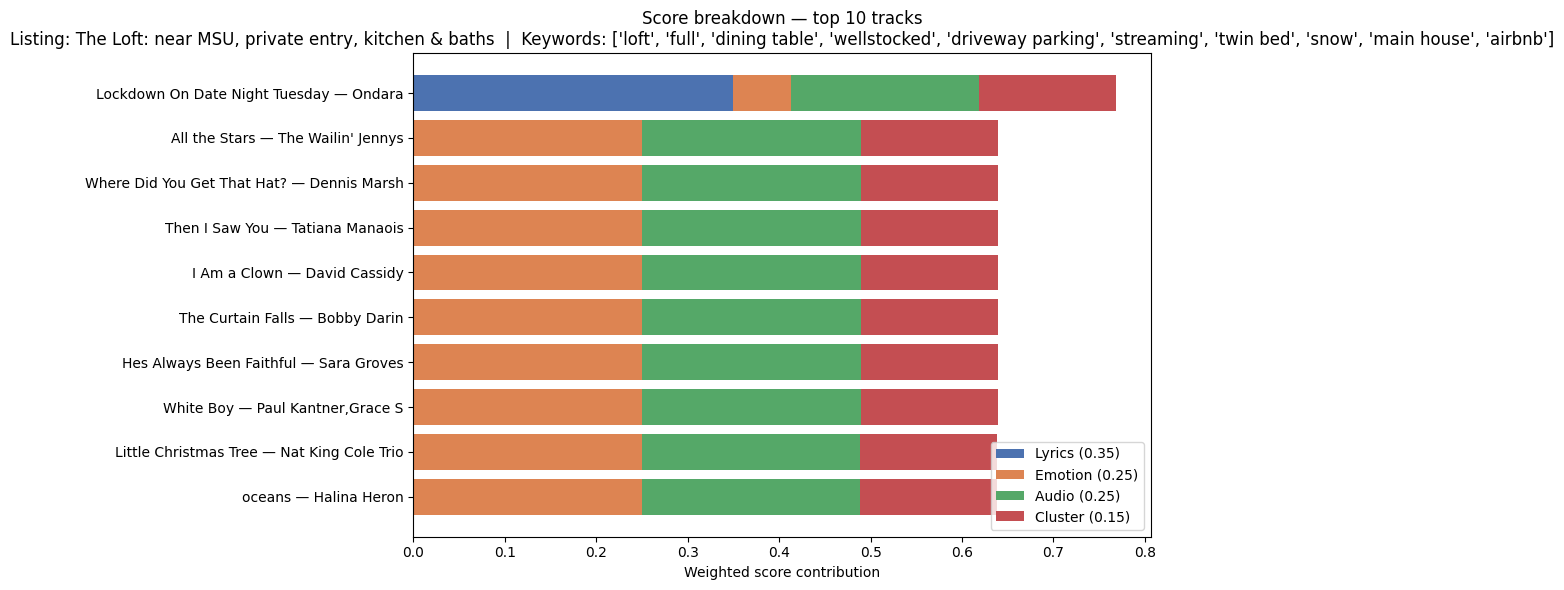

In [21]:
top10 = playlist.head(10).copy()
top10["label"] = top10["track_name"].str[:30] + " — " + top10["artist"].str[:20]

fig, ax = plt.subplots(figsize=(11, 6))
layers  = ["score_lyrics", "score_emotion", "score_audio", "score_cluster"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
labels  = ["Lyrics (0.35)", "Emotion (0.25)", "Audio (0.25)", "Cluster (0.15)"]
weights = [0.35, 0.25, 0.25, 0.15]

bottoms = np.zeros(len(top10))
for layer, color, label, w in zip(layers, colors, labels, weights):
    vals = top10[layer].values * w
    ax.barh(top10["label"], vals, left=bottoms, color=color, label=label)
    bottoms += vals

ax.set_xlabel("Weighted score contribution")
ax.set_title(
    f"Score breakdown — top 10 tracks\n"
    f"Listing: {listing['name']}  |  Keywords: {keywords}"
)
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### B6. Browse multiple listings at once

Generate playlists for the first `N` listings and compare their top track.

In [22]:
N = 5  # number of listings to sample

rows = []
for _, row in df.head(N).iterrows():
    pl = recommend(
        keywords=row['keywords'],
        df=clustered_df,
        scaled_df=scaled_df,
        top_n=1,
    )
    top = pl.iloc[0]
    rows.append({
        "listing_name" : row['name'],
        "keywords"     : row['keywords'],
        "top_track"    : top['track_name'],
        "artist"       : top['artist'],
        "emotion"      : top['emotion'],
        "score"        : round(top['score'], 4),
    })

pd.DataFrame(rows)

,listing_name,keywords,top_track,artist,emotion,score
0,Downtown Bozeman Vacation Rental,"[loft, enjoy private, block historic, perfect ...",We Can Be Together,Jefferson Airplane,joy,0.6421
1,Northside Hideaway,"[need keyless, wifi remote, learningworking, l...",No Big Deal,"Brenda Song,Haley Tju,Anna Akana",surprise,0.6110
2,2 Blocks 2 Main,"[registration, people, detail, number, want, d...",Battlesong,"Deltron 3030,Del The Funky Homosapien,Dan The ...",surprise,0.7415
3,Modern Home Near Campus & Downtown,"[town, great, queen size, sunny, minute, fence...",Seven Shades Of Blue,Beth Nielsen Chapman,joy,0.9851
4,"Charming downtown home, Bogart park","[location, hosting permit, lindley, home locat...",Family Affair Remix,Mary J. Blige,joy,0.9298
